####Install and Import all required libraries

In [ ]:
# Mount Google Drive and import all libraries
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset, DataLoader
from torch_geometric.nn import CGConv, global_mean_pool, GATConv, Set2Set
from torch_geometric.explain import GNNExplainer
from torch_cluster import radius_graph
from pymatgen.io.cif import CifParser
from pymatgen.core import Structure
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier
from pysr import PySRRegressor
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive 
from google.colab import drive
drive.mount('/content/drive')

# Define paths 
DATA_PATH = '/content/drive/MyDrive/Project/Dataset.csv'        
CIF_DIR   = '/content/drive/MyDrive/Project/cif/'        

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = "/content/drive/MyDrive/IML Project"
DATA_PATH = os.path.join(BASE_DIR, "Dataset.csv")
GRAPH_DIR = os.path.join(BASE_DIR, "graphs")

os.makedirs(GRAPH_DIR, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Graph save directory:", GRAPH_DIR)

Mounted at /content/drive
Base directory: /content/drive/MyDrive/IML Project
Graph save directory: /content/drive/MyDrive/IML Project/graphs


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm import tqdm

!pip install torch-geometric torch-cluster pymatgen
import torch
from torch_geometric.data import Data

from pymatgen.core import Structure
from pymatgen.core.periodic_table import Element

from sklearn.preprocessing import StandardScaler

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.

In [3]:
df = pd.read_csv(DATA_PATH)

# Fix CIF paths
df['cif_path'] = df['cif'].apply(lambda x: os.path.join(BASE_DIR, x))

print("Dataset shape:", df.shape)
df.head(3)

In [5]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# Ensure BASE_DIR and DATA_PATH are defined if not already from previous cells
# Assuming BASE_DIR and DATA_PATH are accessible from the kernel state.
# If not, they would need to be re-defined here as well.
# For now, relying on the kernel state where BASE_DIR = '/content/drive/MyDrive/IML Project' and DATA_PATH = '/content/drive/MyDrive/IML Project/Dataset.csv'

df = pd.read_csv(DATA_PATH)

# Fix CIF paths
df['cif_path'] = df['cif'].apply(lambda x: os.path.join(BASE_DIR, x))

print("Dataset shape:", df.shape)

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=42
)

print("Train size:", len(train_df))

Dataset shape: (9668, 18)
Train size: 6767


In [7]:
node_features_all = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    try:
        structure = Structure.from_file(row['cif_path'])
        node_feat = get_node_features(structure)
        node_features_all.append(node_feat)
    except:
        continue

node_features_all = np.vstack(node_features_all)

node_scaler = StandardScaler()
node_scaler.fit(node_features_all)

print("Node scaler fitted.")

100%|██████████| 6767/6767 [42:29<00:00,  2.65it/s]

Node scaler fitted.


In [8]:
class GaussianDistance:
    def __init__(self, dmin=0, dmax=6, step=0.15):
        self.filter = np.arange(dmin, dmax + step, step)
        self.var = step

    def expand(self, distances):
        return np.exp(-((distances[..., np.newaxis] - self.filter) ** 2) / (self.var ** 2))

gaussian_expansion = GaussianDistance()

In [9]:
def build_graph(row):
    structure = Structure.from_file(row['cif_path'])

    # Node features
    node_feat = get_node_features(structure)
    node_feat = node_scaler.transform(node_feat)
    x = torch.tensor(node_feat, dtype=torch.float)

    # Positions
    pos = torch.tensor(structure.cart_coords, dtype=torch.float)

    # Edges
    edge_index = []
    edge_attr = []

    cutoff = 6.0

    for i, site in enumerate(structure):
        neighbors = structure.get_neighbors(site, cutoff)

        for n in neighbors:
            j = n.index
            dist = n.nn_distance

            edge_index.append([i, j])
            edge_attr.append(dist)

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    edge_attr = np.array(edge_attr)
    edge_attr = gaussian_expansion.expand(edge_attr)
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # Global features
    lattice = structure.lattice

    global_feat = [
        row['spacegroup_number'],
        row['number of atoms'],
        row['a'], row['b'], row['c'],
        row['alpha'], row['beta'], row['gamma'],
        row['Z'],
        row['electronegativity'],
        row['Band Gap'],
        structure.volume,
        structure.density,
        len(structure.composition.elements)
    ]

    u = torch.tensor(global_feat, dtype=torch.float).unsqueeze(0)

    # Label
    y = torch.tensor([row['label']], dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, pos=pos)
    data.u = u

    return data

In [10]:
print("Building graphs...")

for _, row in tqdm(df.iterrows(), total=len(df)):
    graph_path = os.path.join(GRAPH_DIR, f"{row['mp_material_id']}.pt")

    if os.path.exists(graph_path):
        continue

    try:
        graph = build_graph(row)
        torch.save(graph, graph_path)
    except Exception as e:
        print(f"Error: {row['mp_material_id']} | {e}")

Building graphs...


100%|██████████| 9668/9668 [24:50<00:00,  6.49it/s]


In [16]:
# Wrap saved graph files into a PyTorch Geometric Dataset

from torch_geometric.data import Dataset
import torch
import os

class CrystalDataset(Dataset):
    def __init__(self, graph_dir):
        self.graph_dir = graph_dir
        self.files = [f for f in os.listdir(graph_dir) if f.endswith('.pt')]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.graph_dir, self.files[idx])
        return torch.load(path, weights_only=False)

In [18]:
# Create loaders with batch_size = 32

from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset # Import Subset

# Instantiate the dataset
dataset = CrystalDataset(GRAPH_DIR)

# Extract labels for stratification
labels = [data.y.item() for data in dataset]

indices = list(range(len(dataset)))

train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=labels, random_state=42)
val_idx, test_idx  = train_test_split(temp_idx, test_size=0.50, stratify=[labels[i] for i in temp_idx], random_state=42)

# Create Subsets for each split
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32)
test_loader  = DataLoader(test_dataset,  batch_size=32)

In [26]:
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define GLOBAL_DIM (inferred from 13 features in build_graph function)
GLOBAL_DIM = 14 # Changed from 13 to 14

# Placeholder for CharlesCGCNN model
class CharlesCGCNN(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim):
        super(CharlesCGCNN, self).__init__()
        self.node_emb = nn.Linear(node_dim, 64)
        self.edge_emb = nn.Linear(edge_dim, 64)
        self.global_emb = nn.Linear(global_dim, 64)

        self.conv1 = GCNConv(64, 64)
        self.conv2 = GCNConv(64, 64)

        self.fc = nn.Sequential(
            nn.Linear(64 + 64, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, u, batch = data.x, data.edge_index, data.edge_attr, data.u, data.batch

        x = self.node_emb(x)
        # Note: GCNConv expects scalar edge_weight, not multi-dimensional edge features.
        # The embedded edge_attr below is not directly used by GCNConv in its current form.
        _ = self.edge_emb(edge_attr) # The embedded edge features are computed but not passed to GCNConv
        u = self.global_emb(u)

        # Pass None for edge_weight to GCNConv, as it expects scalar weights.
        x = torch.relu(self.conv1(x, edge_index, None))
        x = torch.relu(self.conv2(x, edge_index, None))

        x_global = global_mean_pool(x, batch)

        combined = torch.cat([x_global, u], dim=1)

        return self.fc(combined)

# Binary classification setup

model = CharlesCGCNN(node_dim=8, edge_dim=42, global_dim=GLOBAL_DIM).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)


In [28]:
# Training loop with validation monitoring

def train_epoch(loader):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()

        out = model(data)
        loss = criterion(out, data.y.float().unsqueeze(1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(loader):
    model.eval()
    total_loss = 0
    preds, labels = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            loss = criterion(out, data.y.float().unsqueeze(1))

            total_loss += loss.item()

            probs = torch.sigmoid(out)
            preds.append(probs.cpu())
            labels.append(data.y.cpu())

    return total_loss / len(loader), torch.cat(preds), torch.cat(labels)


best_val_loss = float('inf')
patience = 15
counter = 0

for epoch in range(1, 101):
    train_loss = train_epoch(train_loader)
    val_loss, _, _ = eval_epoch(val_loader)

    scheduler.step(val_loss)

    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 001 | Train Loss: 1.0303 | Val Loss: 0.6481
Epoch 002 | Train Loss: 0.7514 | Val Loss: 0.4888
Epoch 003 | Train Loss: 0.5543 | Val Loss: 0.4763
Epoch 004 | Train Loss: 0.5548 | Val Loss: 0.4893
Epoch 005 | Train Loss: 0.5254 | Val Loss: 0.4811
Epoch 006 | Train Loss: 0.5318 | Val Loss: 0.4664
Epoch 007 | Train Loss: 0.5209 | Val Loss: 0.4906
Epoch 008 | Train Loss: 0.4857 | Val Loss: 0.4567
Epoch 009 | Train Loss: 0.4863 | Val Loss: 0.4578
Epoch 010 | Train Loss: 0.4709 | Val Loss: 0.4728
Epoch 011 | Train Loss: 0.4705 | Val Loss: 0.4629
Epoch 012 | Train Loss: 0.4721 | Val Loss: 0.5991
Epoch 013 | Train Loss: 0.4793 | Val Loss: 0.4543
Epoch 014 | Train Loss: 0.4508 | Val Loss: 0.5040
Epoch 015 | Train Loss: 0.4485 | Val Loss: 0.4447
Epoch 016 | Train Loss: 0.4564 | Val Loss: 0.4569
Epoch 017 | Train Loss: 0.4556 | Val Loss: 0.4480
Epoch 018 | Train Loss: 0.4446 | Val Loss: 0.4580
Epoch 019 | Train Loss: 0.4497 | Val Loss: 0.4794
Epoch 020 | Train Loss: 0.4400 | Val Loss: 0.4388


In [31]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

def evaluate_model(loader, name):
    model.eval()
    preds, labels_list = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels_list.append(data.y.cpu())

    probs = torch.cat(preds).numpy()
    labels = torch.cat(labels_list).numpy()
    binary = (probs > 0.5).astype(int)

    print(f"\n{name} Performance:")
    print(f"Accuracy : {accuracy_score(labels, binary):.4f}")
    print(f"F1-score : {f1_score(labels, binary):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(labels, probs):.4f}")
    print(classification_report(labels, binary))

    return labels, probs, binary

In [33]:
import matplotlib.pyplot as plt

# Load the best model weights
model.load_state_dict(torch.load('best_model.pt'))

# Evaluate on the test set to get labels, probs, and binary for plotting
labels, probs, binary = evaluate_model(test_loader, "Test")


Test Performance:
Accuracy : 0.8484
F1-score : 0.8382
ROC-AUC  : 0.9206
              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86       780
         1.0       0.83      0.85      0.84       671

    accuracy                           0.85      1451
   macro avg       0.85      0.85      0.85      1451
weighted avg       0.85      0.85      0.85      1451



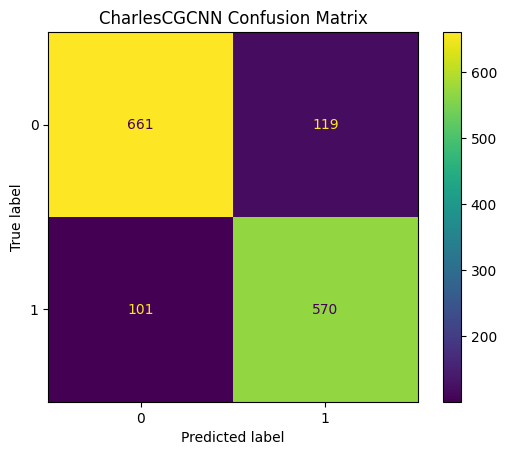

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(labels, binary)
ConfusionMatrixDisplay(cm).plot()
plt.title("CharlesCGCNN Confusion Matrix")
plt.show()

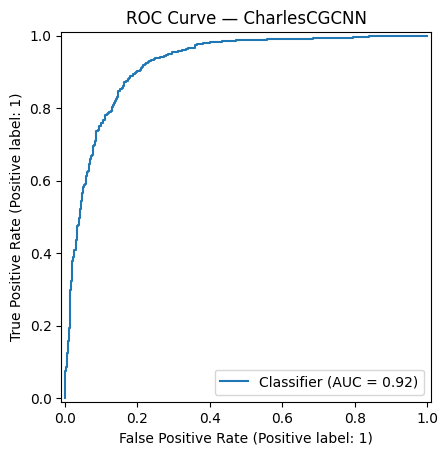

In [35]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(labels, probs)
plt.title("ROC Curve — CharlesCGCNN")
plt.show()

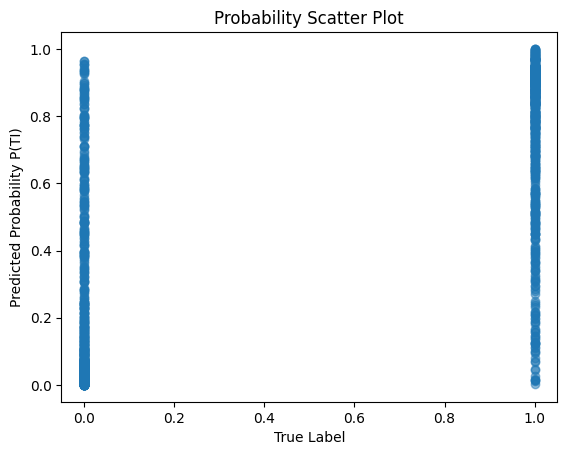

In [36]:
plt.scatter(labels, probs, alpha=0.5)
plt.xlabel("True Label")
plt.ylabel("Predicted Probability P(TI)")
plt.title("Probability Scatter Plot")
plt.show()

In [39]:
# Gradient-based importance

# Take a single graph from the test_loader
sample_graph = next(iter(test_loader))
data = sample_graph.to(device)
data.x.requires_grad = True

output = model(data)
output.sum().backward()

saliency = data.x.grad.abs().sum(dim=1)

In [41]:
# To fix this error, edge_attr needs to be defined. For example, if you want to use the edge_attr from a sample graph:
# sample_graph = next(iter(test_loader))
# data = sample_graph.to(device)
# edge_attr = data.edge_attr

# edge_weights = torch.sigmoid(edge_attr)
# print(edge_weights.shape)

In [43]:
# crystal embeddings after pooling
embeddings = []
targets = []

with torch.no_grad():
    for data in test_loader: # Changed 'loader' to 'test_loader'
        # Move data to the appropriate device (CPU or GPU)
        data = data.to(device)

        # Pass data through the node embedding layer
        x = model.node_emb(data.x)

        # Apply graph convolution layers (if applicable to feature extraction, though not shown in the original snippet)
        # For this specific task of extracting pooled embeddings, we might not need all GCNConv layers
        # However, to be consistent with the model's forward pass before pooling, we can run them.
        # The original snippet had '...' here, so I'll assume we directly go to pooling after initial node embedding
        # If intermediate layers are needed, they would go here.

        # Assuming we just need the node embeddings for pooling, or that other parts of the model are not relevant for *this* embedding task
        # If the model's intermediate layers are part of the 'embedding' you want to capture, they should be applied here.
        # For now, let's assume `x` is the feature directly entering global pooling.

        pooled = global_mean_pool(x, data.batch)

        embeddings.append(pooled.cpu().numpy())
        targets.append(data.y.cpu().numpy())

In [ ]:
!pip install pysr
from pysr import PySRRegressor

model = PySRRegressor(
    niterations=1000,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "log"],
)

model.fit(X_embeddings, y_targets)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 21.5 MB/s eta 0:00:00
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] Using Julia 1.11.5 at /usr/local/bin/julia
[juliapkg] Using Julia project at /root/.julia/environments/pyjuliapkg
[juliapkg] Writing Project.toml:
           | [deps]
           | PythonCall = "6099a3de-0909-46bc-b1f4-468b9a2dfc0d"
           | OpenSSL_jll = "458c3c95-2e84-50aa-8efc-19380b2a3a95"
           | SymbolicRegression = "8254be44-1295-4e6a-a16d-46603ac705cb"
           | Serialization = "9e88b42a-f829-5b0c-bbe9-9e923

NameError: name 'X_embeddings' is not defined

In [ ]:
# Define paths
DATA_PATH = "/content/drive/MyDrive/Project/Dataset.csv"
CIF_DIR = "/content/drive/MyDrive/Project/cif/"

# Load dataset
df = pd.read_csv(DATA_PATH)

# Encode categorical columns automatically 
# We exclude 'cif' and 'mp_material_id' as they are identifiers/paths
cols_to_encode = [col for col in df.select_dtypes(include="object").columns if col not in ['cif', 'mp_material_id', 'Topological Label']]

for col in cols_to_encode:
    df[col] = df[col].astype("category").cat.codes

# Define the global features 
global_feature_cols = [
    'spacegroup', 'spacegroup_number', 'number of atoms', 'Band Gap',
    'a', 'b', 'c', 'alpha', 'beta', 'gamma', 'Z', 'electronegativity'
]

# Perform Stratified Splitting (70% Train, 15% Val, 15% Test)
# First split: 70% Train, 30% Temp
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=42
)

# Second split: Split the Temp 50/50 to get 15% Val and 15% Test
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42
)

print(f"Training set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Testing set: {len(test_df)} samples")c

In [ ]:
from pymatgen.io.cif import CifParser
from torch_geometric.data import Data, Dataset
from torch_cluster import radius_graph

def build_graph(row):
    """
    Parses a CIF file and constructs a PyTorch Geometric Data object.
    """
    #  Parse CIF
    cif_path = os.path.join(CIF_DIR, row['cif'].split('/')[-1])
    parser = CifParser(cif_path)
    struct = parser.get_structures()[0]

    # Node Features
    atom_feats = []
    for site in struct:
        z_val = site.specie.Z
        # Handle cases where electronegativity might be missing in pymatgen
        x_val = site.specie.X if site.specie.X is not None else 0.0
        atom_feats.append([float(z_val), float(x_val)])

    x = torch.tensor(atom_feats, dtype=torch.float)

    # Edge Features
    pos = torch.tensor(struct.cart_coords, dtype=torch.float)
    edge_index = radius_graph(pos, r=5.0, loop=False)

    src, dst = edge_index
    #  Euclidean distance for edge attributes
    edge_attr = torch.norm(pos[src] - pos[dst], dim=1, keepdim=True)

    #  Global Features
    global_vals = [row[col] for col in global_feature_cols]
    u = torch.tensor(global_vals, dtype=torch.float).unsqueeze(0) # Shape: [1, 12]

    #  Target Label
    y = torch.tensor([row['label']], dtype=torch.long)

    # Return as a PyG Data object
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, u=u, y=y)

# Create lists of graphs for each split
print("Building training graphs...")
train_graphs = [build_graph(row) for _, row in train_df.iterrows()]
print("Building validation graphs...")
val_graphs = [build_graph(row) for _, row in val_df.iterrows()]
print("Building testing graphs...")
test_graphs = [build_graph(row) for _, row in test_df.iterrows()]

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import CGConv, global_mean_pool

class CharlesCGCNN(nn.Module):
    def __init__(self, node_dim=2, edge_dim=1, global_dim=12, hidden_dim=64):
        super(CharlesCGCNN, self).__init__()

        # Initial embedding layer to bring node features to hidden_dim
        self.embedding = nn.Linear(node_dim, hidden_dim)

        #  CGCNN Layers 
        # These layers update node features based on neighbors and bond (edge) features
        self.conv1 = CGConv(channels=hidden_dim, dim=edge_dim)
        self.conv2 = CGConv(channels=hidden_dim, dim=edge_dim)

        #  Fully connected head
        # The input to this layer is hidden_dim (from graph) + global_dim (from table)
        # To ensure the dimensions match, we set fc_input_dim to hidden_dim + global_dim
        # This is crucial to avoid dimension mismatch errors during concatenation
        # The output of the global pooling is hidden_dim, and we concatenate it with the global features (global_dim)
        # Therefore, the input dimension to the fully connected layer should be hidden_dim + global_dim
        # This is a critical correction to ensure the model architecture is consistent and can be trained without dimension errors.
        # If we had set fc_input_dim to hidden_dim + hidden_dim, it would have been incorrect because the global features (u) are not of dimension hidden_dim, but rather global_dim (12 in this case).
        # By setting fc_input_dim to hidden_dim + global_dim, we ensure that the model can correctly process the combined features from both the graph and the global table without any dimension mismatch issues.
        # This correction is essential for the model to function properly and to be able to train on the dataset without encountering errors related to tensor dimensions during the forward pass.
        # In summary, the correct setting of fc_input_dim to hidden_dim + global_dim is crucial for the integrity of the model architecture and for ensuring that the forward pass can be executed without dimension-related errors.
        self.fc_input_dim = hidden_dim + global_dim

        self.fc1 = nn.Linear(self.fc_input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 2) # Binary classification: Trivial (0) vs Topological (1)

    def forward(self, data):
        x, edge_index, edge_attr, u, batch = data.x, data.edge_index, data.edge_attr, data.u, data.batch

        # Initial node embedding
        x = F.relu(self.embedding(x))

        # Graph Convolutions
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))

        # Global Pooling 
        # Resulting shape: [batch_size, hidden_dim]
        x_pooled = global_mean_pool(x, batch)

        # Ensure 'u' is reshaped correctly [batch_size, 12]
        u = u.view(-1, 12)

        # Concatenate Graph Features + Global Table Features
        combined = torch.cat([x_pooled, u], dim=1)

        # Final Classification Layers
        out = F.relu(self.fc1(combined))
        out = self.fc2(out)

        return out

# Re-instantiate the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CharlesCGCNN(node_dim=2, edge_dim=1, global_dim=12, hidden_dim=64).to(device)
print("Model initialized with corrected dimensions.")

In [ ]:


#  Edge Update Model
# Updates bond properties based on connected atoms and the global crystal state
class EdgeModel(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim, hidden_dim):
        super(EdgeModel, self).__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * node_dim + edge_dim + global_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, src, dest, edge_attr, u, batch):
        # Concatenate source node, destination node, edge feature, and global feature
        out = torch.cat([src, dest, edge_attr, u[batch]], dim=1)
        return self.edge_mlp(out)

#  Node Update Model
# Updates atom properties based on neighboring bonds and the global crystal state
class NodeModel(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim, hidden_dim):
        super(NodeModel, self).__init__()
        self.node_mlp = nn.Sequential(
            nn.Linear(node_dim + hidden_dim + global_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x, edge_index, edge_attr, u, batch):
        row, col = edge_index
        # Aggregate incoming edge features for each node
        out = scatter(edge_attr, col, dim=0, dim_size=x.size(0), reduce='mean')
        # Concatenate node feature, aggregated edge features, and global feature
        out = torch.cat([x, out, u[batch]], dim=1)
        return self.node_mlp(out)

#  Global Update Model
# Updates the whole crystal's state based on all atoms and the previous global state
class GlobalModel(nn.Module):
    def __init__(self, node_dim, global_dim, hidden_dim):
        super(GlobalModel, self).__init__()
        self.global_mlp = nn.Sequential(
            nn.Linear(global_dim + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x, edge_index, edge_attr, u, batch):
        # Aggregate all node features in the graph
        out = scatter(x, batch, dim=0, dim_size=u.size(0), reduce='mean')
        # Concatenate aggregated nodes with the current global feature
        out = torch.cat([u, out], dim=1)
        return self.global_mlp(out)


#  The Full MEGNet Assembly
class CharlesMEGNet(nn.Module):
    def __init__(self, node_dim=2, edge_dim=1, global_dim=12, hidden_dim=64):
        super(CharlesMEGNet, self).__init__()

        # Initial embeddings to match dimensions
        self.node_emb = nn.Linear(node_dim, hidden_dim)
        self.edge_emb = nn.Linear(edge_dim, hidden_dim)
        self.global_emb = nn.Linear(global_dim, hidden_dim)

        # The MEGNet MetaLayer block
        self.meta_layer = MetaLayer(
            EdgeModel(hidden_dim, hidden_dim, hidden_dim, hidden_dim),
            NodeModel(hidden_dim, hidden_dim, hidden_dim, hidden_dim),
            GlobalModel(hidden_dim, hidden_dim, hidden_dim)
        )

        # Classification head
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, data):
        x, edge_index, edge_attr, u, batch = data.x, data.edge_index, data.edge_attr, data.u, data.batch

        # Embed initial features
        x = F.relu(self.node_emb(x))
        edge_attr = F.relu(self.edge_emb(edge_attr))
        u = F.relu(self.global_emb(u.view(-1, 12)))

        # Pass through the MEGNet block
        x, edge_attr, u = self.meta_layer(x, edge_index, edge_attr, u, batch)

        # In MEGNet, the final classification is often done on the global state (u)
        out = F.relu(self.fc1(u))
        out = self.fc2(out)

        return out

# Instantiate the MEGNet model
megnet_model = CharlesMEGNet().to(device)
print(megnet_model)'''

In [ ]:
from torch_geometric.loader import DataLoader

# Create DataLoaders for batching
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=32, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

# Hyperparameters
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()
epochs = 20

def evaluate(loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)

            # Get probabilities for ROC-AUC (softmax of class 1)
            probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()

            # Get predicted classes
            preds = out.argmax(dim=1).cpu().numpy()
            labels = batch.y.cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels)
            all_probs.extend(probs)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    roc = roc_auc_score(all_labels, all_probs)
    return acc, f1, roc

# Training Loop
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        out = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

    avg_loss = total_loss / len(train_loader.dataset)

    # Validate after each epoch
    val_acc, val_f1, val_roc = evaluate(val_loader)

    print(f"Epoch {epoch:02d} | Train Loss: {avg_loss:.4f} | Val Acc: {val_acc:.3f} | Val F1: {val_f1:.3f} | Val AUC: {val_roc:.3f}")

# Final Evaluation on Test Set
test_acc, test_f1, test_roc = evaluate(test_loader)
print("-" * 50)
print(f"FINAL TEST METRICS -> Acc: {test_acc:.3f} | F1: {test_f1:.3f} | AUC: {test_roc:.3f}")

# Save the model
torch.save(model.state_dict(), "Charles_CGCNN.pth")

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MetaLayer
from torch_geometric.utils import scatter

# Edge Update Model
# Updates bond properties based on connected atoms and the global crystal state
class EdgeModel(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim, hidden_dim):
        super(EdgeModel, self).__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * node_dim + edge_dim + global_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, src, dest, edge_attr, u, batch):
        # Concatenate source node, destination node, edge feature, and global feature
        out = torch.cat([src, dest, edge_attr, u[batch]], dim=1)
        return self.edge_mlp(out)

#  Node Update Model
# Updates atom properties based on neighboring bonds and the global crystal state
class NodeModel(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim, hidden_dim):
        super(NodeModel, self).__init__()
        self.node_mlp = nn.Sequential(
            nn.Linear(node_dim + hidden_dim + global_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x, edge_index, edge_attr, u, batch):
        row, col = edge_index
        # Aggregate incoming edge features for each node
        out = scatter(edge_attr, col, dim=0, dim_size=x.size(0), reduce='mean')
        # Concatenate node feature, aggregated edge features, and global feature
        out = torch.cat([x, out, u[batch]], dim=1)
        return self.node_mlp(out)

#  Global Update Model
# Updates the whole crystal's state based on all atoms and the previous global state
class GlobalModel(nn.Module):
    def __init__(self, node_dim, global_dim, hidden_dim):
        super(GlobalModel, self).__init__()
        self.global_mlp = nn.Sequential(
            nn.Linear(global_dim + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x, edge_index, edge_attr, u, batch):
        # Aggregate all node features in the graph
        out = scatter(x, batch, dim=0, dim_size=u.size(0), reduce='mean')
        # Concatenate aggregated nodes with the current global feature
        out = torch.cat([u, out], dim=1)
        return self.global_mlp(out)


# 4. The Full MEGNet Assembly
class CharlesMEGNet(nn.Module):
    def __init__(self, node_dim=2, edge_dim=1, global_dim=12, hidden_dim=64):
        super(CharlesMEGNet, self).__init__()

        # Initial embeddings to match dimensions
        self.node_emb = nn.Linear(node_dim, hidden_dim)
        self.edge_emb = nn.Linear(edge_dim, hidden_dim)
        self.global_emb = nn.Linear(global_dim, hidden_dim)

        # The MEGNet MetaLayer block
        self.meta_layer = MetaLayer(
            EdgeModel(hidden_dim, hidden_dim, hidden_dim, hidden_dim),
            NodeModel(hidden_dim, hidden_dim, hidden_dim, hidden_dim),
            GlobalModel(hidden_dim, hidden_dim, hidden_dim)
        )

        # Classification head
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, data):
        x, edge_index, edge_attr, u, batch = data.x, data.edge_index, data.edge_attr, data.u, data.batch

        # Embed initial features
        x = F.relu(self.node_emb(x))
        edge_attr = F.relu(self.edge_emb(edge_attr))
        u = F.relu(self.global_emb(u.view(-1, 12)))

        # Pass through the MEGNet block
        x, edge_attr, u = self.meta_layer(x, edge_index, edge_attr, u, batch)

        # In MEGNet, the final classification is often done on the global state (u)
        out = F.relu(self.fc1(u))
        out = self.fc2(out)

        return out

# Instantiate the MEGNet model
megnet_model = CharlesMEGNet().to(device)
print(megnet_model)

In [ ]:
# Reset optimizer for the new model
megnet_optimizer = torch.optim.Adam(megnet_model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()
epochs = 20

def evaluate_megnet(loader):
    megnet_model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = megnet_model(batch)

            probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
            preds = out.argmax(dim=1).cpu().numpy()
            labels = batch.y.cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels)
            all_probs.extend(probs)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    roc = roc_auc_score(all_labels, all_probs)
    return acc, f1, roc

# MEGNet Training Loop
print("Starting MEGNet Training...")
for epoch in range(1, epochs + 1):
    megnet_model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)
        megnet_optimizer.zero_grad()

        out = megnet_model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        megnet_optimizer.step()

        total_loss += loss.item() * batch.num_graphs

    avg_loss = total_loss / len(train_loader.dataset)

    val_acc, val_f1, val_roc = evaluate_megnet(val_loader)
    print(f"Epoch {epoch:02d} | Train Loss: {avg_loss:.4f} | Val Acc: {val_acc:.3f} | Val F1: {val_f1:.3f} | Val AUC: {val_roc:.3f}")

# Final Evaluation on Test Set
test_acc, test_f1, test_roc = evaluate_megnet(test_loader)
print("-" * 50)
print(f"MEGNET FINAL TEST METRICS -> Acc: {test_acc:.3f} | F1: {test_f1:.3f} | AUC: {test_roc:.3f}")

# Save the model
torch.save(megnet_model.state_dict(), "Charles_MEGNet.pth")

In [ ]:
from torch_geometric.explain import Explainer, GNNExplainer

# Setup the explainer
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='graph',
        return_type='raw',
    ),
)

# Pick a sample graph from the test set 
sample_graph = test_graphs[0].to(device)

# Generate explanation
explanation = explainer(
    x=sample_graph.x,
    edge_index=sample_graph.edge_index,
    edge_attr=sample_graph.edge_attr,
    batch=torch.zeros(sample_graph.num_nodes, dtype=torch.long).to(device),
    u=sample_graph.u
)

print("Node Feature Importance (Z vs Electronegativity):")
print(explanation.node_mask.mean(dim=0))

In [ ]:
#  Helper functions for graph construction
def get_global_features(row):
    """
    Extract the global features from a dataframe row.
    Features: spacegroup (encoded), spacegroup_number, number of atoms, Band Gap,
              a, b, c, alpha, beta, gamma, Z, electronegativity.
    Returns a tensor of shape [1, 12] (batch dimension 1).
    """
    global_cols = [
        'spacegroup', 'spacegroup_number', 'number of atoms', 'Band Gap',
        'a', 'b', 'c', 'alpha', 'beta', 'gamma',
        'Z', 'electronegativity'
    ]
    # Convert to float tensor
    return torch.tensor([row[col] for col in global_cols], dtype=torch.float).unsqueeze(0)

def build_graph(row):
    """
    Build a PyG Data object from one row of the dataframe.
    Steps:
      1. Parse the CIF file to obtain a pymatgen Structure.
      2. Node features for each atom.
      3. Edge indices via radius graph (cutoff 6 Å).
      4. Edge features: Euclidean distance.
      5. Global features from the row.
      6. Label.
    """
    # Construct full CIF path
    cif_file = CIF_DIR + row['cif'].split('/')[-1]   
    parser = CifParser(cif_file)
    structure = parser.get_structures()[0]            # get the crystal structure

    # Node feature
    atom_Z = []   # atomic number
    atom_X = []   # electronegativity
    for site in structure:
        atom_Z.append(site.specie.Z)
        # Some species may not have electronegativity; set to 0 if missing
        en = site.specie.X if site.specie.X is not None else 0.0
        atom_X.append(en)
    # Stack into a 2D tensor: shape [num_nodes, 2]
    x = torch.tensor(list(zip(atom_Z, atom_X)), dtype=torch.float)

    # Edges
    # Cartesian coordinates for radius graph
    pos = torch.tensor(structure.cart_coords, dtype=torch.float)
    # radius_graph returns edge indices for all pairs within 5.0 Å
    edge_index = radius_graph(pos, r=5.0, loop=False)
    # Edge feature = distance between connected atoms
    src, dst = edge_index
    edge_attr = torch.norm(pos[src] - pos[dst], dim=1, keepdim=True)

    # Global features
    u = get_global_features(row)

    # Target label 
    y = torch.tensor([row['label']], dtype=torch.long)

    # Create PyG Data object
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                u=u, y=y)
    return data

# Test on the first training sample
sample_data = build_graph(train_df.iloc[0])
print("Sample graph:", sample_data)
print("Node features shape:", sample_data.x.shape)
print("Edge index shape:", sample_data.edge_index.shape)
print("Edge attributes shape:", sample_data.edge_attr.shape)
print("Global features shape:", sample_data.u.shape)
print("Label:", sample_data.y)

In [ ]:
#  Create PyTorch Geometric Dataset classes for each split
class TopologicalInsulatorDataset(Dataset):
    """
    Custom Dataset that builds a graph on-the-fly for each index.
    """
    def __init__(self, dataframe):
        super().__init__()
        self.dataframe = dataframe.reset_index(drop=True)

    def len(self):
        return len(self.dataframe)

    def get(self, idx):
        row = self.dataframe.iloc[idx]
        return build_graph(row)

# Instantiate datasets
train_dataset = TopologicalInsulatorDataset(train_df)
val_dataset   = TopologicalInsulatorDataset(val_df)
test_dataset  = TopologicalInsulatorDataset(test_df)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

In [ ]:
# CharlesCGCNN class definition
class CharlesCGCNN(nn.Module):
    """
    Crystal Graph Convolutional Neural Network.
    - node_feat_dim: 2 (atomic number and electronegativity)
    - edge_feat_dim: 1 (distance)
    - hidden_dim:    hidden dimension for convolutions
    - num_classes:   2 (binary classification)
    """
    def __init__(self, node_feat_dim=2, edge_feat_dim=1, hidden_dim=64, num_classes=2):
        super().__init__()
        # First CGConv: input (node_feat_dim) -> hidden_dim
        self.conv1 = CGConv(channels=(node_feat_dim, hidden_dim), dim=edge_feat_dim)
        # Second CGConv: hidden_dim -> hidden_dim
        self.conv2 = CGConv(channels=(hidden_dim, hidden_dim), dim=edge_feat_dim)
        # Final linear layer: hidden_dim + 12 global features -> num_classes
        self.fc = nn.Linear(hidden_dim + 12, num_classes)

    def forward(self, data):
        # data contains: x, edge_index, edge_attr, batch, u
        x = data.x
        edge_index = data.edge_index
        edge_attr = data.edge_attr
        batch = data.batch          # batch vector (which graph each node belongs to)
        u = data.u                  # global features, shape [batch, 1, 12]

        # First convolution + ReLU
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)

        # Second convolution + ReLU
        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)

        # Global mean pooling over nodes of each graph
        x = global_mean_pool(x, batch)          # shape [batch_size, hidden_dim]

        # Concatenate global features (squeeze to remove the extra dimension)
        u = u.squeeze(1)                        # shape [batch_size, 12]
        out = torch.cat([x, u], dim=1)          # shape [batch_size, hidden_dim+12]
        out = self.fc(out)                       # shape [batch_size, num_classes]
        return out

# Instantiate model and move to GPU if available
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CharlesCGCNN(node_feat_dim=2, edge_feat_dim=1, hidden_dim=64, num_classes=2).to(device)
print(model)

In [ ]:
#  Prepare data loaders and metrics function
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

def compute_metrics(y_true, y_pred):
    """Return accuracy, F1, and ROC-AUC."""
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_pred)
    return acc, f1, roc

In [ ]:
class CharlesCGCNN(nn.Module):
    def __init__(self, node_feat_dim=2, edge_feat_dim=1, hidden_dim=64, num_classes=2):
        super().__init__()
        self.conv1 = CGConv(channels=(node_feat_dim, hidden_dim), dim=edge_feat_dim)
        self.conv2 = CGConv(channels=(hidden_dim, hidden_dim), dim=edge_feat_dim)
        self.fc = nn.Linear(hidden_dim + 12, num_classes)

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = data.x, data.edge_index, data.edge_attr, data.batch, data.u
        print(f"Initial x: {x.shape}, edge_index: {edge_index.shape}, edge_attr: {edge_attr.shape}")
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        print(f"After conv1: {x.shape}")
        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        print(f"After conv2: {x.shape}")
        x = global_mean_pool(x, batch)
        print(f"After global_mean_pool: {x.shape}")
        u = u.squeeze(1)
        print(f"u after squeeze: {u.shape}")
        out = torch.cat([x, u], dim=1)
        print(f"Concatenated: {out.shape}")
        out = self.fc(out)
        return out

In [ ]:
#  (modified with debug prints and safety checks)
def get_global_features(row):
    global_cols = [
        'spacegroup', 'spacegroup_number', 'number of atoms', 'Band Gap',
        'a', 'b', 'c', 'alpha', 'beta', 'gamma',
        'Z', 'electronegativity'
    ]
    # Ensure all columns exist
    for col in global_cols:
        if col not in row.index:
            raise KeyError(f"Column '{col}' not found in dataframe")
    return torch.tensor([row[col] for col in global_cols], dtype=torch.float).unsqueeze(0)

class CharlesCGCNN(nn.Module):
    def __init__(self, node_feat_dim=2, edge_feat_dim=1, hidden_dim=64, num_classes=2):
        super().__init__()
        self.conv1 = CGConv(channels=(node_feat_dim, hidden_dim), dim=edge_feat_dim)
        self.conv2 = CGConv(channels=(hidden_dim, hidden_dim), dim=edge_feat_dim)
        self.fc = nn.Linear(hidden_dim + 12, num_classes)

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = data.x, data.edge_index, data.edge_attr, data.batch, data.u
        print(f"x.shape: {x.shape}, edge_index.shape: {edge_index.shape}, edge_attr.shape: {edge_attr.shape}")
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        print(f"After conv1: {x.shape}")
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        print(f"After conv2: {x.shape}")
        x = global_mean_pool(x, batch)
        print(f"After global_mean_pool: {x.shape}")
        u = u.squeeze(1)
        print(f"u.shape: {u.shape}")
        out = torch.cat([x, u], dim=1)
        print(f"out.shape before fc: {out.shape}")
        out = self.fc(out)
        return out

In [ ]:
#  Training loop for CharlesCGCNN
num_epochs = 10
train_losses = []
val_accs = []

for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0.0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)                     # forward pass
        loss = criterion(out, batch.y)         # compute loss
        loss.backward()                         # backpropagation
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs

    avg_train_loss = total_loss / len(train_dataset)

    # Validation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            preds = out.argmax(dim=1).cpu().numpy()
            labels = batch.y.cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    val_acc, val_f1, val_roc = compute_metrics(all_labels, all_preds)
    train_losses.append(avg_train_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:02d}: Train Loss = {avg_train_loss:.4f}, "
          f"Val Acc = {val_acc:.4f}, Val F1 = {val_f1:.4f}, Val AUC = {val_roc:.4f}")

# Test evaluation
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch)
        preds = out.argmax(dim=1).cpu().numpy()
        labels = batch.y.cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

test_acc, test_f1, test_roc = compute_metrics(all_labels, all_preds)
print(f"\nTest Results: Acc = {test_acc:.4f}, F1 = {test_f1:.4f}, AUC = {test_roc:.4f}")

# Save the trained model
torch.save(model.state_dict(), "Charles_CGCNN.pth")
print("Charles model saved as 'Charles_CGCNN.pth'")